In [3]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cmcrameri import cm

# Load data

In [4]:
ds_ERA5_pl=xr.open_dataset('/Users/sofiehedetoft/Library/CloudStorage/OneDrive-Personligt/KU/Msc Climate Change/Kurser Bern/Seminar_in _Climatology/Iran_data/ERA5_05_DewPoints_Iran_pl_2025-07-31_06UTC.nc')
ds_ERA5_sfc=xr.open_dataset('/Users/sofiehedetoft/Library/CloudStorage/OneDrive-Personligt/KU/Msc Climate Change/Kurser Bern/Seminar_in _Climatology/Iran_data/ERA5_05_DewPoints_Iran_sfc_2025-07-31_06UTC.nc')
ds_AIFS_pl=xr.open_dataset('/Users/sofiehedetoft/Library/CloudStorage/OneDrive-Personligt/KU/Msc Climate Change/Kurser Bern/Seminar_in _Climatology/Iran_data/AIFS-ENS_05_DewPoints_Iran_pl_2025-07-31_06UTC.nc')
ds_AIFS_sfc=xr.open_dataset('/Users/sofiehedetoft/Library/CloudStorage/OneDrive-Personligt/KU/Msc Climate Change/Kurser Bern/Seminar_in _Climatology/Iran_data/AIFS-ENS_05_DewPoints_Iran_sfc_2025-07-31_06UTC.nc')

#change from Kelvin to Celcius
ds_AIFS_sfc=ds_AIFS_sfc.assign(d2m_C=lambda ds_AIFS_sfc: (ds_AIFS_sfc.d2m-273.15))
ds_AIFS_pl=ds_AIFS_pl.assign(t_C=lambda ds_AIFS_pl: (ds_AIFS_pl.t-273.15))
ds_ERA5_pl=ds_ERA5_pl.assign(t_C=lambda ds_ERA5_pl: (ds_ERA5_pl.t-273.15))
ds_ERA5_sfc=ds_ERA5_sfc.assign(d2m_C=lambda ds_ERA5_sfc: (ds_ERA5_sfc.d2m-273.15))


In [5]:
#change from K to C in the variable description of units for all 4
# ds_ERA5_pl.t_C.GRIB_units

ds_ERA5_pl

<xarray.Dataset> Size: 2MB
Dimensions:        (isobaricInhPa: 10, latitude: 81, longitude: 161)
Coordinates:
  * isobaricInhPa  (isobaricInhPa) float64 80B 1e+03 925.0 900.0 ... 300.0 250.0
  * latitude       (latitude) float64 648B 35.0 34.75 34.5 ... 15.5 15.25 15.0
  * longitude      (longitude) float64 1kB 35.0 35.25 35.5 ... 74.5 74.75 75.0
    number         int64 8B ...
    time           datetime64[ns] 8B ...
    step           timedelta64[ns] 8B ...
    valid_time     datetime64[ns] 8B ...
Data variables:
    q              (isobaricInhPa, latitude, longitude) float32 522kB ...
    t              (isobaricInhPa, latitude, longitude) float32 522kB 300.2 ....
    t_C            (isobaricInhPa, latitude, longitude) float32 522kB 27.08 ....
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-17T10:39 GRIB to CDM+CF via cfgrib-0.9.1...

# Results version 4

Focus on dew points only.
Zoom in on the area - see plots to be made in the notes from the meeting

Coordinates of interest: 
Coordinates:
26 N 54.25 E 27.5 N 57.5 E

## Set area

In [6]:
ds_ERA5_pl=ds_ERA5_pl.sel(latitude=slice(27.5,26), longitude=slice(54.25,57.5))
ds_ERA5_sfc=ds_ERA5_sfc.sel(latitude=slice(27.5,26), longitude=slice(54.25,57.5))
ds_AIFS_pl=ds_AIFS_pl.sel(latitude=slice(27.5,26), longitude=slice(54.25,57.5))
ds_AIFS_sfc=ds_AIFS_sfc.sel(latitude=slice(27.5,26), longitude=slice(54.25,57.5))

ds_AIFS_pl

<xarray.Dataset> Size: 2MB
Dimensions:        (ensemble_members: 50, leadtime: 10, isobaricInhPa: 3,
                    latitude: 7, longitude: 14)
Coordinates:
    number         (ensemble_members) int64 400B ...
  * leadtime       (leadtime) int64 80B 1 2 3 4 5 6 7 8 9 10
    fc_init_time   (leadtime) datetime64[ns] 80B ...
    fc_valid_time  (leadtime) datetime64[ns] 80B ...
  * isobaricInhPa  (isobaricInhPa) float64 24B 1e+03 700.0 500.0
  * latitude       (latitude) float64 56B 27.5 27.25 27.0 26.75 26.5 26.25 26.0
  * longitude      (longitude) float64 112B 54.25 54.5 54.75 ... 57.0 57.25 57.5
Dimensions without coordinates: ensemble_members
Data variables:
    t              (ensemble_members, leadtime, isobaricInhPa, latitude, longitude) float32 588kB ...
    q              (ensemble_members, leadtime, isobaricInhPa, latitude, longitude) float32 588kB ...
    t_C            (ensemble_members, leadtime, isobaricInhPa, latitude, longitude) float32 588kB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-17T13:28 GRIB to CDM+CF via cfgrib-0.9.1...

## Plot AIFS 2 m dewpoint with leadtime 10

In [8]:
# Ensemble mean
ens_mean = ds_AIFS_sfc.mean(dim="ensemble_members")

In [9]:
# max and min
print("Max value in ensemble mean:", ens_mean.d2m_C.max().values)
print("Min value in ensemble mean:", ens_mean.d2m_C.min().values)

Max value in ensemble mean: 30.466866
Min value in ensemble mean: 8.610944


RuntimeError: Colorbar layout of new layout engine not compatible with old engine, and a colorbar has been created.  Engine not changed.

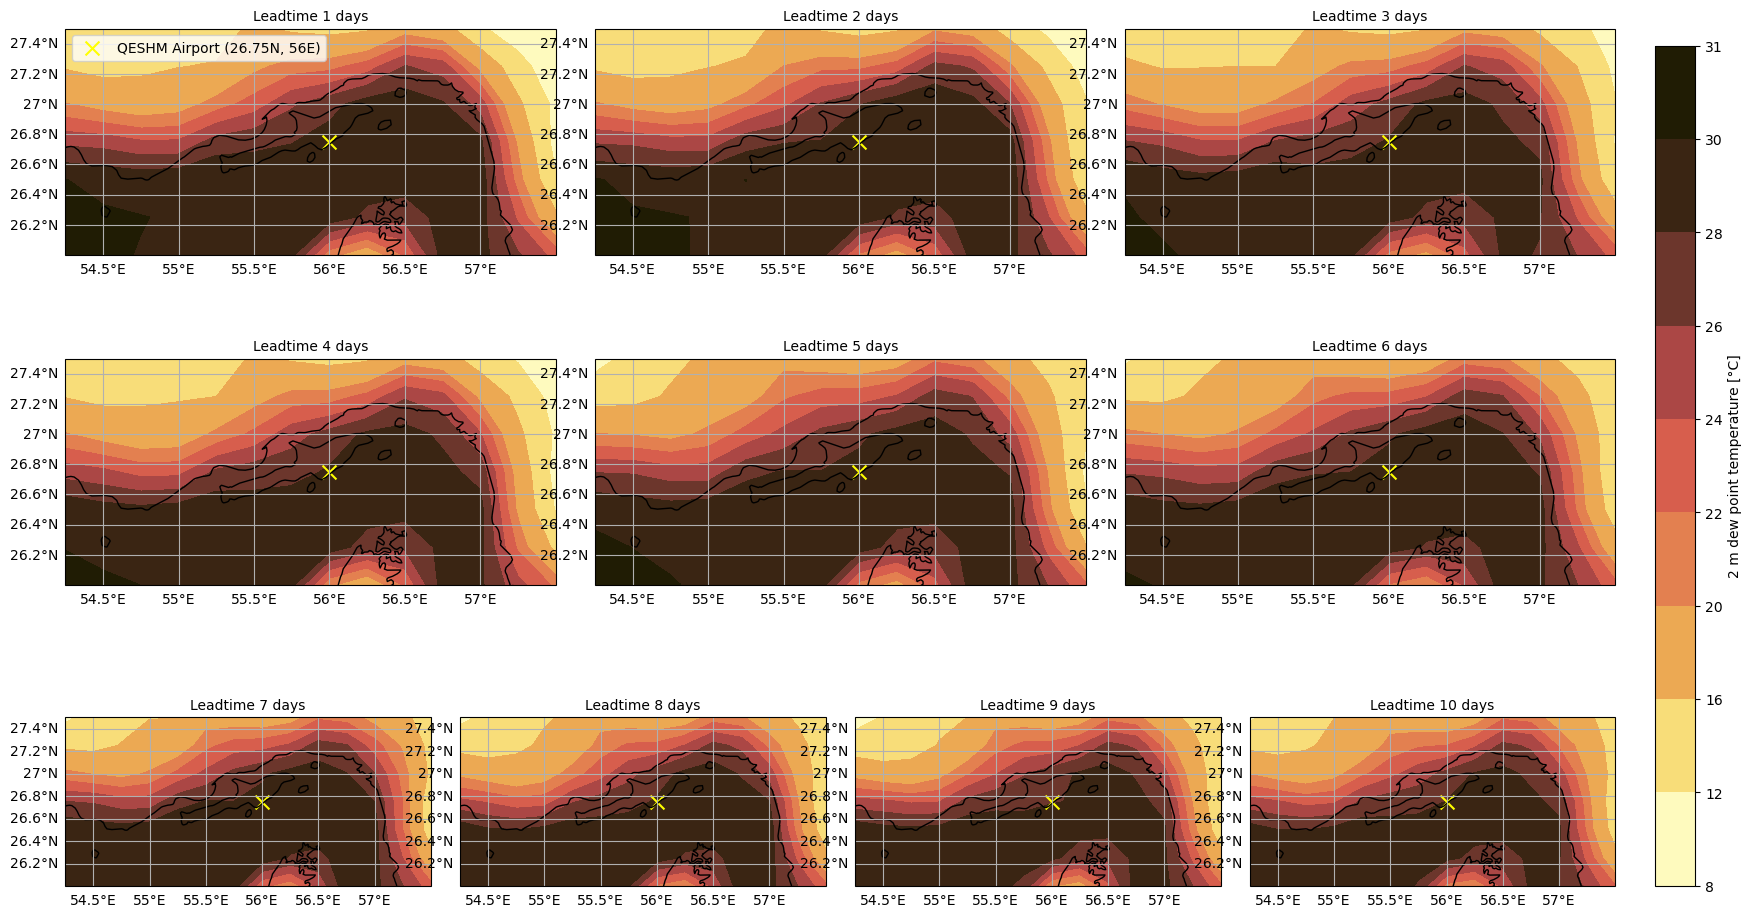

In [57]:


# Map projection
map_projection = ccrs.PlateCarree()

# Color levels

# vmin, vcenter, vmax = 8, 0, 31
# norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)
# levels=np.linspace(vmin, vmax, )

# Create 2x5 subplot grid
# fig, axes = plt.subplots(2, 5, figsize=(20, 8),
#                          subplot_kw={'projection': map_projection})
# axes = axes.flatten()

norm = mcolors.PowerNorm(gamma=1.6, vmin=8, vmax=31)

#levels=np.linspace(8,31,10)
levels=[8,12,16,20,22,24,26,28,30,31]
# 3 rows: 4 plots on top, then 3, then 3  (total = 10)
fig = plt.figure(figsize=(20, 12), constrained_layout=True)
outer = fig.add_gridspec(3, 1, hspace=0.25)

gs_r1 = outer[0].subgridspec(1, 3, wspace=0.08)  # 4 plots
gs_r2 = outer[1].subgridspec(1, 3, wspace=0.08)  # 3 plots
gs_r3 = outer[2].subgridspec(1, 4, wspace=0.08)  # 3 plots

axes = []
for j in range(3):
    axes.append(fig.add_subplot(gs_r1[0, j], projection=map_projection))
for j in range(3):
    axes.append(fig.add_subplot(gs_r2[0, j], projection=map_projection))
for j in range(4):
    axes.append(fig.add_subplot(gs_r3[0, j], projection=map_projection))

for i, lt in enumerate(ens_mean.leadtime.values):
    ax = axes[i]
    
    # Select leadtime
    ds_sel = ens_mean.sel(leadtime=lt)

    
    # Plot wind speed (matplotlib contourf)
    cf = ax.contourf(
        ds_sel.longitude,
        ds_sel.latitude,
        ds_sel['d2m_C'],
        levels=levels,
        norm=norm,
        # cmap='seismic',
        cmap=cm.lajolla_r, #colormap here, change it to IPCC
        # vmin=0,
        # vmax=20, #after outcommenting the colors changed
        transform=map_projection
    )
    
    
    # Add coastlines
    ax.add_feature(cfeature.COASTLINE, linestyle='-')
    
    # Add subplot title
    ax.set_title(f'Leadtime {lt} days', fontsize=10)

    gl = ax.gridlines(draw_labels=True)
    gl.top_labels = False
    gl.right_labels = False

    ax.scatter(56, 26.75, color='yellow', marker='x', s=100, label='QESHM Airport (26.75N, 56E)', transform=map_projection)
    if i == 0:
        ax.legend(loc='upper left')
# Add single shared colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
fig.colorbar(cf, cax=cbar_ax, label=r'2 m dew point temperature [°C]')

plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space for colorbar



## Leadtime evolution with differences from day to day

Because differences are very hard to predict

RuntimeError: Colorbar layout of new layout engine not compatible with old engine, and a colorbar has been created.  Engine not changed.

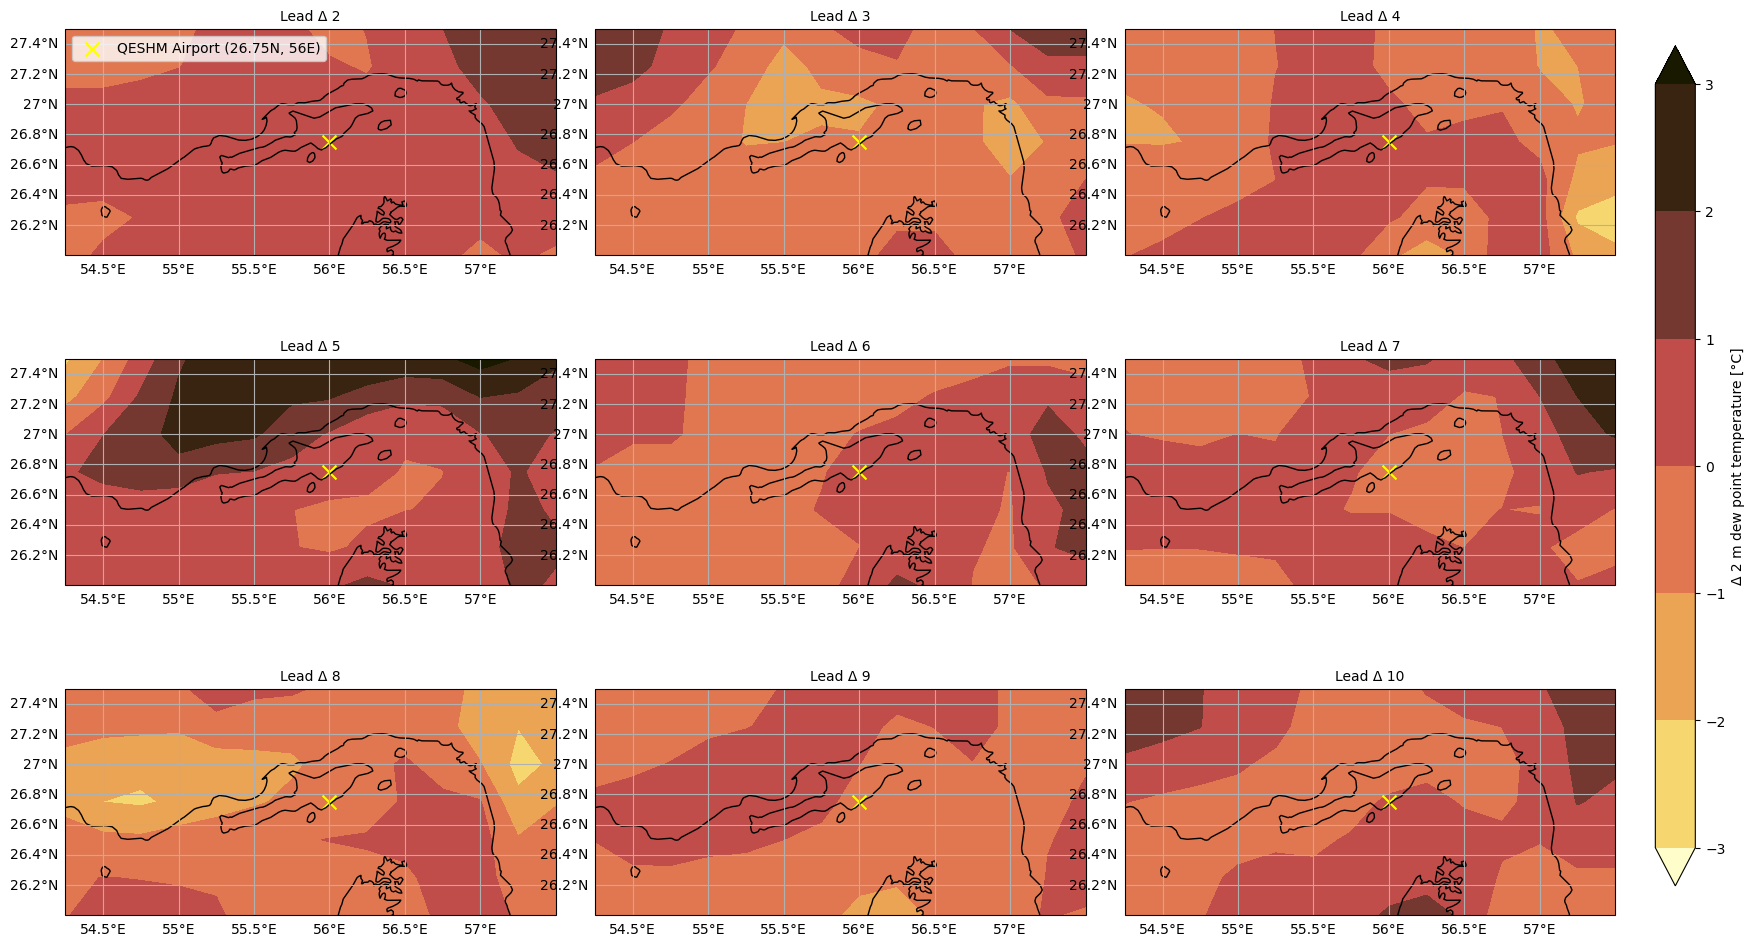

In [56]:
diff=ens_mean.d2m_C.diff('leadtime')
# Compute differences along the lead-time dimension using xarray (keeps coords).
# Detect the leadtime dimension name robustly (some datasets use 'leadtime' or 'lt').
if 'leadtime' in ens_mean.dims:
    lead_dim = 'leadtime'
elif 'lt' in ens_mean.dims:
    lead_dim = 'lt'
else:
    # fall back: pick the first non-spatial, non-ensemble dim as lead dim
    lead_dim = None
    for d in ens_mean.dims:
        if d not in ('latitude', 'longitude', 'lat', 'lon', 'ensemble_members', 'time', 'valid_time', 'step', 'number'):
            lead_dim = d
            break
    if lead_dim is None:
        raise ValueError('Could not determine leadtime dimension name')

# diff will be an xarray DataArray with one fewer step along the lead-dim
diff = ens_mean.d2m_C.diff(dim=lead_dim)

# Prepare map and normalization for differences (diverging around zero)
map_projection = ccrs.PlateCarree()
absmax = float(np.nanmax(np.abs(diff.values)))
if absmax == 0 or np.isnan(absmax):
    absmax = 1.0
norm = mcolors.TwoSlopeNorm(vmin=-absmax, vcenter=0, vmax=absmax)
#levels = np.linspace(-absmax, absmax, 10)
levels= [-3, -2, -1, 0, 1, 2, 3] #change the levels to make the colors more distinct

# Create 9-panel layout (4,3,2) to show the first up-to-9 diffs
fig = plt.figure(figsize=(20, 12), constrained_layout=True)
outer = fig.add_gridspec(3, 1, hspace=0.25)
gs_r1 = outer[0].subgridspec(1, 3, wspace=0.08)  # 4 plots
gs_r2 = outer[1].subgridspec(1, 3, wspace=0.08)  # 3 plots
gs_r3 = outer[2].subgridspec(1, 3, wspace=0.08)  # 2 plots (total = 9)
axes = []
for j in range(3):
    axes.append(fig.add_subplot(gs_r1[0, j], projection=map_projection))
for j in range(3):
    axes.append(fig.add_subplot(gs_r2[0, j], projection=map_projection))
for j in range(3):
    axes.append(fig.add_subplot(gs_r3[0, j], projection=map_projection))

# number of available diffs along the lead dim
n_leads = diff.sizes[lead_dim]
n_to_plot = min(n_leads, 9)

for i in range(n_to_plot):
    ax = axes[i]
    # select the i-th diff slice
    ds_sel = diff.isel({lead_dim: i})

    # get lon/lat coords (fall back if names differ)
    if 'longitude' in ds_sel.coords:
        lon = ds_sel.longitude
    elif 'lon' in ds_sel.coords:
        lon = ds_sel.lon
    else:
        lon = ds_sel.coords[list(ds_sel.coords)[-1]]

    if 'latitude' in ds_sel.coords:
        lat = ds_sel.latitude
    elif 'lat' in ds_sel.coords:
        lat = ds_sel.lat
    else:
        lat = ds_sel.coords[list(ds_sel.coords)[-2]]

    cf = ax.contourf(
        lon,
        lat,
        ds_sel,
        levels=levels,
        norm=norm,
        cmap=cm.lajolla_r,
        transform=map_projection,
        extend='both'
    )

    ax.add_feature(cfeature.COASTLINE, linestyle='-')
    try:
        lead_val = np.asarray(diff[lead_dim].values[i])
    except Exception:
        lead_val = i
    ax.set_title(f'Lead Δ {lead_val}', fontsize=10)
    ax.scatter(56, 26.75, color='yellow', marker='x', s=100, label='QESHM Airport (26.75N, 56E)', transform=map_projection)
    if i == 0:
        ax.legend(loc='upper left')
    gl = ax.gridlines(draw_labels=True)
    gl.top_labels = False
    gl.right_labels = False

# Add single shared colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
fig.colorbar(cf, cax=cbar_ax, label=r'Δ 2 m dew point temperature [°C]')

plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space for colorbar
plt.show()

diff

Lead Δ 2 is the difference from leadtime 1 to leadtime 2

Leadtime 1 is the day closest to the event: 

### AIFS boxplot leadtime evolution before time of interest

when did the AI first time encapture the extreme level?

make a dataset with ensemble members and leadtime but no one spatial dimension, that is define the airports coordinates as the point of interest

26°45′16.70″N 055°54′08.47″E (translated to 26.75 and 56)

In [28]:

AIFS_qeshm=ds_AIFS_sfc.sel(longitude=56, latitude=26.75)

AIFS_qeshm

<xarray.Dataset> Size: 5kB
Dimensions:            (ensemble_members: 50, leadtime: 10)
Coordinates:
    number             (ensemble_members) int64 400B ...
  * leadtime           (leadtime) int64 80B 1 2 3 4 5 6 7 8 9 10
    fc_init_time       (leadtime) datetime64[ns] 80B ...
    fc_valid_time      (leadtime) datetime64[ns] 80B ...
    heightAboveGround  float64 8B ...
    latitude           float64 8B 26.75
    longitude          float64 8B 56.0
Dimensions without coordinates: ensemble_members
Data variables:
    d2m                (ensemble_members, leadtime) float32 2kB 301.5 ... 300.6
    d2m_C              (ensemble_members, leadtime) float32 2kB 28.34 ... 27.43
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-17T11:08 GRIB to CDM+CF via cfgrib-0.9.1...

In [29]:
#find the ground truth value for the event via ERA5 data at the given coordinates

ERA5_qeshm=ds_ERA5_sfc.sel(longitude=56, latitude=26.75)

ERA5_qeshm

<xarray.Dataset> Size: 64B
Dimensions:     ()
Coordinates:
    number      int64 8B ...
    time        datetime64[ns] 8B ...
    step        timedelta64[ns] 8B ...
    surface     float64 8B ...
    latitude    float64 8B 26.75
    longitude   float64 8B 56.0
    valid_time  datetime64[ns] 8B ...
Data variables:
    d2m         float32 4B 300.0
    d2m_C       float32 4B 26.83
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-17T10:39 GRIB to CDM+CF via cfgrib-0.9.1...

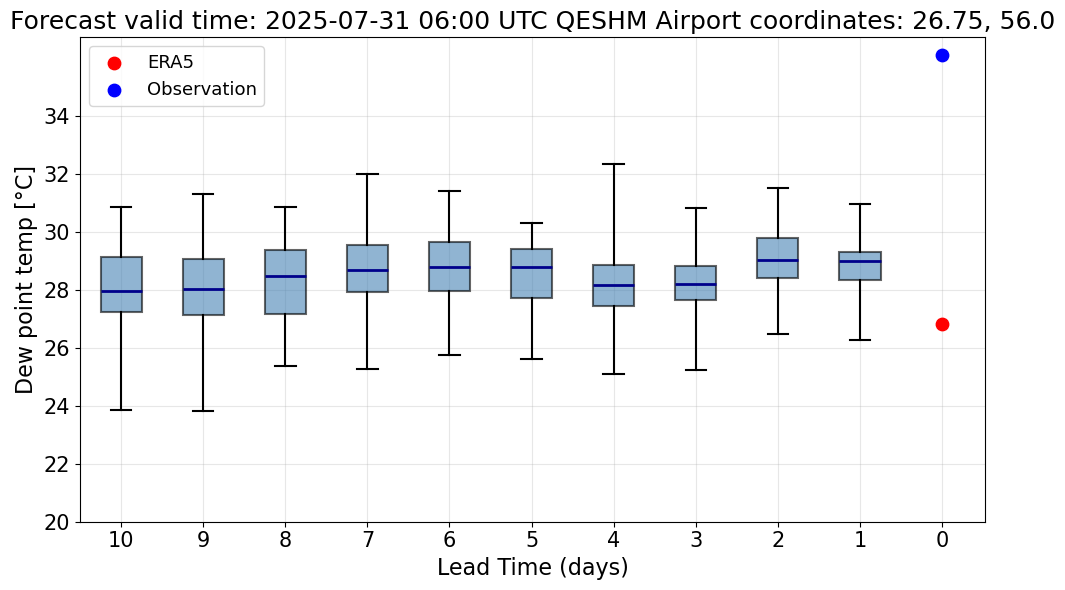

In [30]:
plt.figure(figsize=(10, 6))

leadtimes = np.arange(1, 10+1, 1)
n_leads = len(leadtimes)

# Reverse data so leadtime 10 days appears first #
data_reversed = AIFS_qeshm.d2m_C[:, ::-1]

box = plt.boxplot(
    data_reversed,
    positions=np.arange(1, n_leads + 1),
    whis=[0, 100],
    showfliers=False,
    patch_artist=True,                # allows color filling
    boxprops=dict(facecolor="steelblue", alpha=0.6, linewidth=1.5),
    medianprops=dict(color="darkblue", linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5)
)

# ERA5 point
plt.scatter(
    n_leads + 1,
    ERA5_qeshm.d2m_C,
    color="red",
    marker="o",
    s=80,
    zorder=5,
    label="ERA5"
)

#real dew point temo
plt.scatter(
    n_leads+1,
    36.1, #observation
    color="blue",
    marker="o",
    s=80,
    zorder=5,
    label="Observation"
)

# Tick labels
xtick_positions = np.arange(1, n_leads + 2)
xtick_labels = list(leadtimes[::-1]) + [0]

plt.xticks(xtick_positions, xtick_labels, fontsize=15)
plt.yticks(fontsize=15)

# valid_time = pd.to_datetime(ds_AIFS.fc_valid_time.values[0])
# time_str = valid_time.strftime("%Y-%m-%d %H:%M")

plt.title("Forecast valid time: 2025-07-31 06:00 UTC QESHM Airport coordinates: 26.75, 56.0", fontsize=18)

plt.xlabel("Lead Time (days)", fontsize=16)
plt.ylabel("Dew point temp [°C]", fontsize=16)
plt.yticks(np.arange(20,33+2,2))

plt.legend(fontsize=13,loc='upper left')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Leadtime boxplot evolution of humidity and temp to check if this fits with ERA5



## temperature and humidity at 1000 hpa

In [31]:
#prepare data:
AIFS_qeshm_1000=ds_AIFS_pl.sel(longitude=56, latitude=26.75)


In [32]:
AIFS_qeshm_1000=AIFS_qeshm_1000.sel(isobaricInhPa=1000)

In [33]:
#ERA5 temp

ERA5_qeshm_1000=ds_ERA5_pl.sel(longitude=56, latitude=26.75)

ERA5_qeshm_1000=ERA5_qeshm_1000.sel(isobaricInhPa=1000)
ERA5_qeshm_1000

<xarray.Dataset> Size: 68B
Dimensions:        ()
Coordinates:
    number         int64 8B ...
    time           datetime64[ns] 8B ...
    step           timedelta64[ns] 8B ...
    isobaricInhPa  float64 8B 1e+03
    latitude       float64 8B 26.75
    longitude      float64 8B 56.0
    valid_time     datetime64[ns] 8B ...
Data variables:
    q              float32 4B ...
    t              float32 4B 310.3
    t_C            float32 4B 37.19
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-17T10:39 GRIB to CDM+CF via cfgrib-0.9.1...

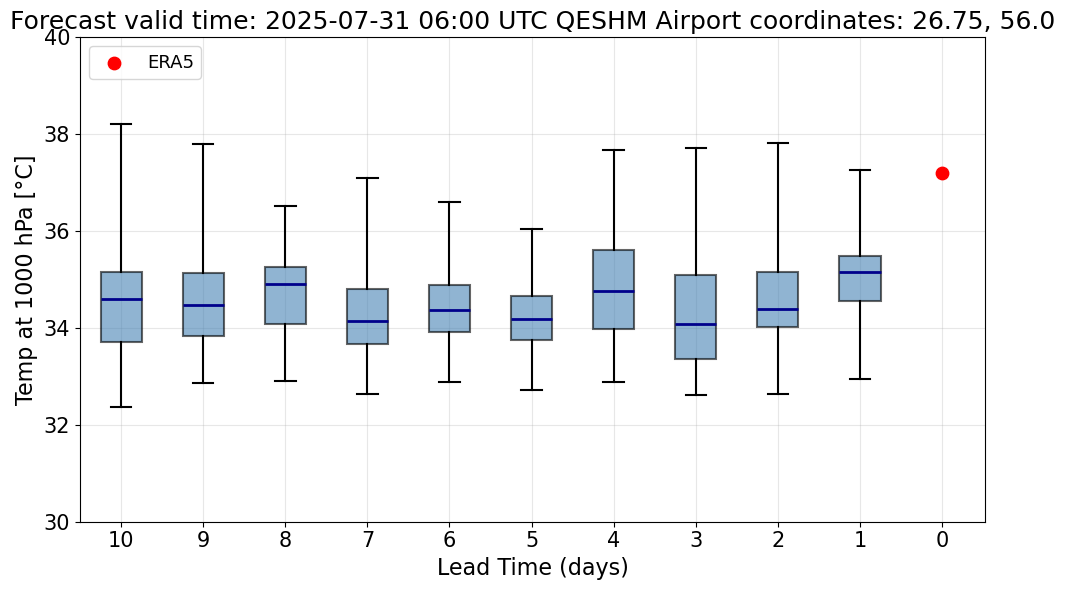

In [35]:
#boxplots
plt.figure(figsize=(10, 6))

leadtimes = np.arange(1, 10+1, 1)
n_leads = len(leadtimes)

# Reverse data so leadtime 10 days appears first #
data_reversed = AIFS_qeshm_1000.t_C[:, ::-1]


box = plt.boxplot(
    data_reversed,
    positions=np.arange(1, n_leads + 1),
    whis=[0, 100],
    showfliers=False,
    patch_artist=True,                # allows color filling
    boxprops=dict(facecolor="steelblue", alpha=0.6, linewidth=1.5),
    medianprops=dict(color="darkblue", linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5)
)

# ERA5 point
plt.scatter(
    n_leads + 1,
    ERA5_qeshm_1000.t_C,
    color="red",
    marker="o",
    s=80,
    zorder=5,
    label="ERA5"
)

#real temp
# plt.scatter(
#     n_leads+1,
#     36.1, #observation
#     color="blue",
#     marker="o",
#     s=80,
#     zorder=5,
#     label="Observation"
# )

# Tick labels
xtick_positions = np.arange(1, n_leads + 2)
xtick_labels = list(leadtimes[::-1]) + [0]

plt.xticks(xtick_positions, xtick_labels, fontsize=15)
plt.yticks(fontsize=15)

# valid_time = pd.to_datetime(ds_AIFS.fc_valid_time.values[0])
# time_str = valid_time.strftime("%Y-%m-%d %H:%M")

plt.title("Forecast valid time: 2025-07-31 06:00 UTC QESHM Airport coordinates: 26.75, 56.0", fontsize=18)

plt.xlabel("Lead Time (days)", fontsize=16)
plt.ylabel("Temp at 1000 hPa [°C]", fontsize=16)
plt.yticks(np.arange(30,40+2,2))


plt.legend(fontsize=13,loc='upper left')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [36]:
AIFS_qeshm_1000.q.max()

<xarray.DataArray 'q' ()> Size: 4B
array(0.02784424, dtype=float32)
Coordinates:
    isobaricInhPa  float64 8B 1e+03
    latitude       float64 8B 26.75
    longitude      float64 8B 56.0
Attributes: (12/31)
    GRIB_paramId:                             133
    GRIB_dataType:                            pf
    GRIB_numberOfPoints:                      13041
    GRIB_typeOfLevel:                         isobaricInhPa
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_shortName:                           q
    GRIB_totalNumber:                         51
    GRIB_units:                               kg kg**-1
    long_name:                                Specific humidity
    units:                                    kg kg**-1
    standard_name:                            specific_humidity

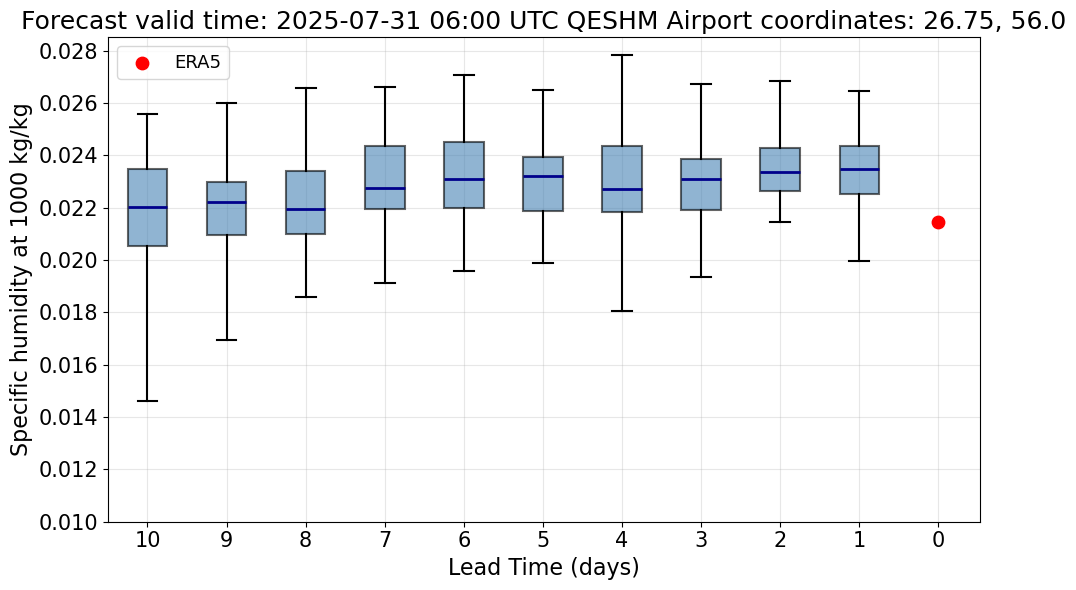

In [37]:
#boxplots
plt.figure(figsize=(10, 6))

leadtimes = np.arange(1, 10+1, 1)
n_leads = len(leadtimes)

# Reverse data so leadtime 10 days appears first #
data_reversed = AIFS_qeshm_1000.q[:, ::-1]


box = plt.boxplot(
    data_reversed,
    positions=np.arange(1, n_leads + 1),
    whis=[0, 100],
    showfliers=False,
    patch_artist=True,                # allows color filling
    boxprops=dict(facecolor="steelblue", alpha=0.6, linewidth=1.5),
    medianprops=dict(color="darkblue", linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5)
)

# ERA5 point
plt.scatter(
    n_leads + 1,
    ERA5_qeshm_1000.q,
    color="red",
    marker="o",
    s=80,
    zorder=5,
    label="ERA5"
)

#real temp
# plt.scatter(
#     n_leads+1,
#     36.1, #observation
#     color="blue",
#     marker="o",
#     s=80,
#     zorder=5,
#     label="Observation"
# )

# Tick labels
xtick_positions = np.arange(1, n_leads + 2)
xtick_labels = list(leadtimes[::-1]) + [0]

plt.xticks(xtick_positions, xtick_labels, fontsize=15)
plt.yticks(fontsize=15)

# valid_time = pd.to_datetime(ds_AIFS.fc_valid_time.values[0])
# time_str = valid_time.strftime("%Y-%m-%d %H:%M")

plt.title("Forecast valid time: 2025-07-31 06:00 UTC QESHM Airport coordinates: 26.75, 56.0", fontsize=18)

plt.xlabel("Lead Time (days)", fontsize=16)
plt.ylabel("Specific humidity at 1000 kg/kg", fontsize=16)
plt.yticks(np.arange(0.01,0.03,0.002))


plt.legend(fontsize=13,loc='upper left')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

(array([[ 0.,  0.,  0.,  0.,  2., 12., 18., 10.,  8.,  0.],
        [ 0.,  0.,  0.,  0.,  0., 12., 21.,  9.,  7.,  1.],
        [ 0.,  0.,  0.,  3.,  6., 10., 18., 11.,  1.,  1.],
        [ 0.,  0.,  1.,  3.,  5., 15., 12.,  8.,  5.,  1.],
        [ 0.,  0.,  0.,  1.,  7., 10., 17., 12.,  3.,  0.],
        [ 0.,  0.,  0.,  1.,  8.,  9., 15., 10.,  6.,  1.],
        [ 0.,  0.,  0.,  3.,  4., 15., 13., 10.,  4.,  1.],
        [ 0.,  0.,  1.,  5.,  9., 16.,  8.,  9.,  1.,  1.],
        [ 0.,  1.,  2.,  4., 10., 16.,  9.,  6.,  2.,  0.],
        [ 1.,  1.,  0.,  3., 13., 11., 14.,  6.,  1.,  0.]]),
 array([0.01462448, 0.01594645, 0.01726843, 0.01859041, 0.01991238,
        0.02123436, 0.02255633, 0.02387831, 0.02520029, 0.02652226,
        0.02784424]),
 <a list of 10 BarContainer objects>)

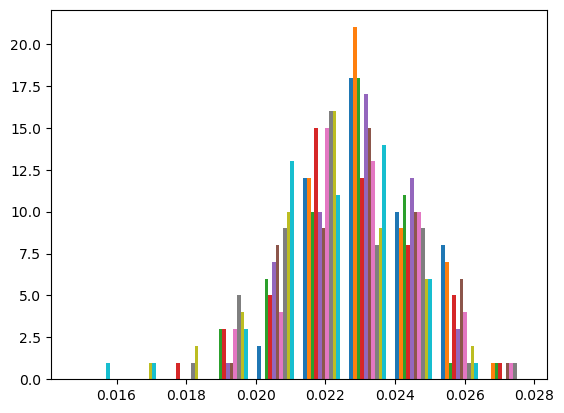

In [38]:
plt.hist(AIFS_qeshm_1000.q)

# ERA 5 maps 

Here I produce ERA5 map of the subset region

In [50]:
print(ds_ERA5_sfc.d2m_C.min())


<xarray.DataArray 'd2m_C' ()> Size: 4B
array(8.192291, dtype=float32)
Coordinates:
    number      int64 8B ...
    time        datetime64[ns] 8B ...
    step        timedelta64[ns] 8B ...
    surface     float64 8B ...
    valid_time  datetime64[ns] 8B ...
Attributes: (12/31)
    GRIB_paramId:                             168
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      13041
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_shortName:                           2d
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre dewpoint temperature
    units:                                    K
    standard_name:                            unknown


/opt/anaconda3/envs/s_ccr_env/lib/python3.12/site-packages/matplotlib/colors.py:2903: RuntimeWarning: overflow encountered in power
  resdat[resdat > 0] = np.power(resdat[resdat > 0], gamma)
/opt/anaconda3/envs/s_ccr_env/lib/python3.12/site-packages/matplotlib/colors.py:2903: RuntimeWarning: overflow encountered in power
  resdat[resdat > 0] = np.power(resdat[resdat > 0], gamma)
/opt/anaconda3/envs/s_ccr_env/lib/python3.12/site-packages/matplotlib/colors.py:2903: RuntimeWarning: overflow encountered in power
  resdat[resdat > 0] = np.power(resdat[resdat > 0], gamma)
/opt/anaconda3/envs/s_ccr_env/lib/python3.12/site-packages/matplotlib/colors.py:2903: RuntimeWarning: overflow encountered in power
  resdat[resdat > 0] = np.power(resdat[resdat > 0], gamma)
/opt/anaconda3/envs/s_ccr_env/lib/python3.12/site-packages/matplotlib/colors.py:2903: RuntimeWarning: overflow encountered in power
  resdat[resdat > 0] = np.power(resdat[resdat > 0], gamma)


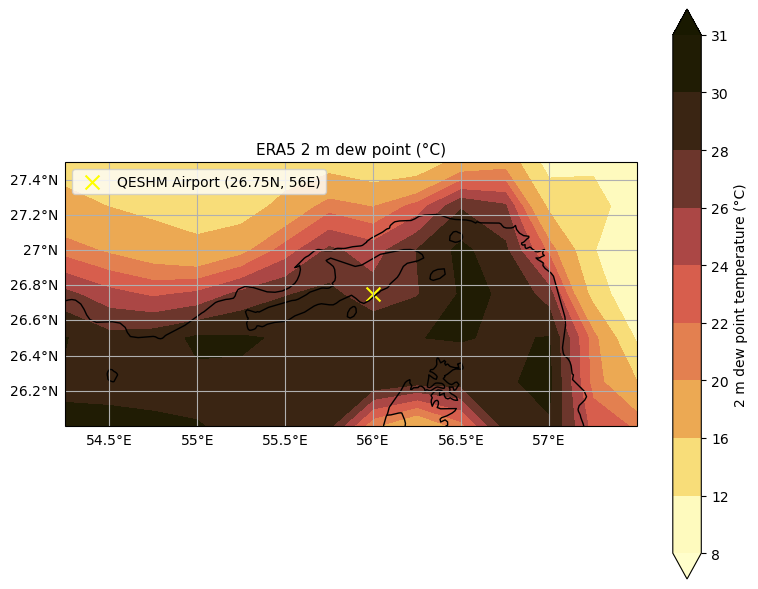

In [54]:
# ERA5: usually no ensemble_members/leadtime dimensions
map_projection = ccrs.PlateCarree()

# Start from dew point in degC and reduce any singleton extra dims
era5_plot = ds_ERA5_sfc["d2m_C"]
for dim in ["valid_time", "time", "step", "leadtime", "ensemble_members", "number"]:
    if dim in era5_plot.dims:
        era5_plot = era5_plot.isel({dim: 0})

# absmax = np.nanmax(np.abs(era5_plot.values))
# norm = mcolors.TwoSlopeNorm(vmin=-2, vcenter=0, vmax=absmax)
norm = mcolors.PowerNorm(gamma=1.6, vmin=8, vmax=31)

# levels = np.linspace(-2, absmax, 34)
#levels =np.arange(-2,32,1)
levels=[8,12,16,20,22,24,26,28,30,31]

#V_levels = np.arange(-5, 35, 1)

fig, ax = plt.subplots(1, 1, figsize=(8, 6), subplot_kw={"projection": map_projection})

cf = ax.contourf(
    era5_plot.longitude,
    era5_plot.latitude,
    era5_plot,
    levels=levels,
    norm=norm,
    cmap=cm.lajolla_r, #vik before 
    transform=map_projection,
    extend="both"
)

ax.add_feature(cfeature.COASTLINE, linestyle='-')
ax.add_feature(cfeature.BORDERS)
ax.scatter(56, 26.75, color='yellow', marker='x', s=100, label='QESHM Airport (26.75N, 56E)', transform=map_projection)
ax.legend(loc='upper left')
gl = ax.gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False

ax.set_title("ERA5 2 m dew point (°C)", fontsize=11)
fig.colorbar(cf, ax=ax, label="2 m dew point temperature (°C)")
plt.tight_layout()

In [40]:
era5_plot.max()

<xarray.DataArray 'd2m_C' ()> Size: 4B
array(30.559479, dtype=float32)
Coordinates:
    number      int64 8B ...
    time        datetime64[ns] 8B ...
    step        timedelta64[ns] 8B ...
    surface     float64 8B ...
    valid_time  datetime64[ns] 8B ...
Attributes: (12/31)
    GRIB_paramId:                             168
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      13041
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_shortName:                           2d
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre dewpoint temperature
    units:                                    K
    standard_name:                            unknown

# Bias check between ERA5 and AIFS

In [41]:
print("leadtime values:", ens_mean.leadtime.values)


leadtime values: [ 1  2  3  4  5  6  7  8  9 10]


In [42]:
ds_AIFS_sfc

#we need one ensemble average - dataset already created
ens_mean

#but now I have 10 leadtime - leadtime 1 is closest to the event

ens_mean_event=ens_mean.sel(leadtime=1)

ens_mean_event


<xarray.Dataset> Size: 984B
Dimensions:            (latitude: 7, longitude: 14)
Coordinates:
  * latitude           (latitude) float64 56B 27.5 27.25 27.0 ... 26.25 26.0
  * longitude          (longitude) float64 112B 54.25 54.5 54.75 ... 57.25 57.5
    fc_init_time       datetime64[ns] 8B ...
    heightAboveGround  float64 8B ...
    fc_valid_time      datetime64[ns] 8B ...
    leadtime           int64 8B 1
Data variables:
    d2m                (latitude, longitude) float32 392B 285.7 287.0 ... 296.4
    d2m_C              (latitude, longitude) float32 392B 12.54 13.81 ... 23.23
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-17T11:08 GRIB to CDM+CF via cfgrib-0.9.1...

In [43]:
print(ens_mean_event.fc_valid_time.values) #do not change the time when I change leadtime...
print("coords:", list(ds_AIFS_sfc.coords))

2025-07-31T06:00:00.000000000
coords: ['number', 'fc_init_time', 'heightAboveGround', 'latitude', 'longitude', 'fc_valid_time', 'leadtime']


In [44]:
ds_ERA5_sfc

<xarray.Dataset> Size: 992B
Dimensions:     (latitude: 7, longitude: 14)
Coordinates:
  * latitude    (latitude) float64 56B 27.5 27.25 27.0 26.75 26.5 26.25 26.0
  * longitude   (longitude) float64 112B 54.25 54.5 54.75 ... 57.0 57.25 57.5
    number      int64 8B ...
    time        datetime64[ns] 8B ...
    step        timedelta64[ns] 8B ...
    surface     float64 8B ...
    valid_time  datetime64[ns] 8B ...
Data variables:
    d2m         (latitude, longitude) float32 392B 287.8 287.8 ... 296.4 294.9
    d2m_C       (latitude, longitude) float32 392B 14.6 14.63 ... 23.24 21.7
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-17T10:39 GRIB to CDM+CF via cfgrib-0.9.1...

## Bias evaluation

Here AIFS leadtime 1 is subtracted ERA5.
NB need to verify the time AIFS corresponds to

The lat long are from the same subset and the dimensions now fit. Ensemble mean is used for AIFS

In [45]:
bias=ds_ERA5_sfc.d2m_C-ens_mean_event.d2m_C

print(bias.values)

print(bias.to_dataframe(name="df_bias").reset_index())

[[ 2.0642576e+00  8.1937504e-01 -5.7839870e-01 -7.0406246e-01
  -1.0177736e+00 -3.4496479e+00 -1.2087698e+00 -2.3660936e+00
  -2.7241020e+00 -1.1169338e+00  1.3059769e+00 -2.3429880e+00
   1.6886330e+00  2.5032225e+00]
 [ 1.4533987e+00  1.1425781e+00 -3.2966805e-01 -2.0753317e+00
  -2.5026360e+00 -2.0295506e+00  1.4171982e-01 -1.4753304e+00
  -1.7718697e-01  1.6544342e+00  1.2266998e+00 -3.8865032e+00
  -1.3699245e-01  7.3429680e-01]
 [ 1.0039253e+00  7.1753883e-01  2.2646523e-01 -1.5224018e+00
  -1.8292179e+00 -1.5811920e-03  6.9429779e-01 -2.2292957e+00
  -9.2672157e-01  1.3072815e+00  2.4287224e-01 -3.7766399e+00
  -4.5001755e+00 -2.6267967e+00]
 [ 1.1013107e+00 -4.8128700e-01 -6.0156059e-01  1.4845848e-01
  -3.0290985e-01  2.6929855e-01  5.9033394e-01 -2.0336170e+00
  -1.0389099e+00  1.0632782e+00  8.3337593e-01 -1.4646912e+00
  -4.9368744e+00 -2.4953318e+00]
 [ 5.9097290e-02 -8.3799171e-01 -1.3377380e-01  7.7345276e-01
   3.0292511e-01  7.2704697e-01  2.2318077e-01  2.6091385e-01


In [46]:
#print(f'max bias {bias.max()} and min bias {bias.min()}')

bias.max()

<xarray.DataArray 'd2m_C' ()> Size: 4B
array(2.5032225, dtype=float32)
Coordinates:
    number             int64 8B ...
    time               datetime64[ns] 8B ...
    step               timedelta64[ns] 8B ...
    surface            float64 8B ...
    valid_time         datetime64[ns] 8B ...
    fc_init_time       datetime64[ns] 8B ...
    heightAboveGround  float64 8B ...
    fc_valid_time      datetime64[ns] 8B 2025-07-31T06:00:00
    leadtime           int64 8B 1
Attributes: (12/27)
    GRIB_paramId:                             168
    GRIB_numberOfPoints:                      13041
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    GRIB_gridType:                            regular_ll
    GRIB_uvRelativeToGrid:                    0
    ...                                       ...
    GRIB_name:                                2 metre dewpoint temperature
    GRIB_shortName:                           2d
    GRIB_units:                               K
    long_name:                                2 metre dewpoint temperature
    units:                                    K
    standard_name:                            unknown

In [47]:
bias.min()

<xarray.DataArray 'd2m_C' ()> Size: 4B
array(-4.9368744, dtype=float32)
Coordinates:
    number             int64 8B ...
    time               datetime64[ns] 8B ...
    step               timedelta64[ns] 8B ...
    surface            float64 8B ...
    valid_time         datetime64[ns] 8B ...
    fc_init_time       datetime64[ns] 8B ...
    heightAboveGround  float64 8B ...
    fc_valid_time      datetime64[ns] 8B 2025-07-31T06:00:00
    leadtime           int64 8B 1
Attributes: (12/27)
    GRIB_paramId:                             168
    GRIB_numberOfPoints:                      13041
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    GRIB_gridType:                            regular_ll
    GRIB_uvRelativeToGrid:                    0
    ...                                       ...
    GRIB_name:                                2 metre dewpoint temperature
    GRIB_shortName:                           2d
    GRIB_units:                               K
    long_name:                                2 metre dewpoint temperature
    units:                                    K
    standard_name:                            unknown

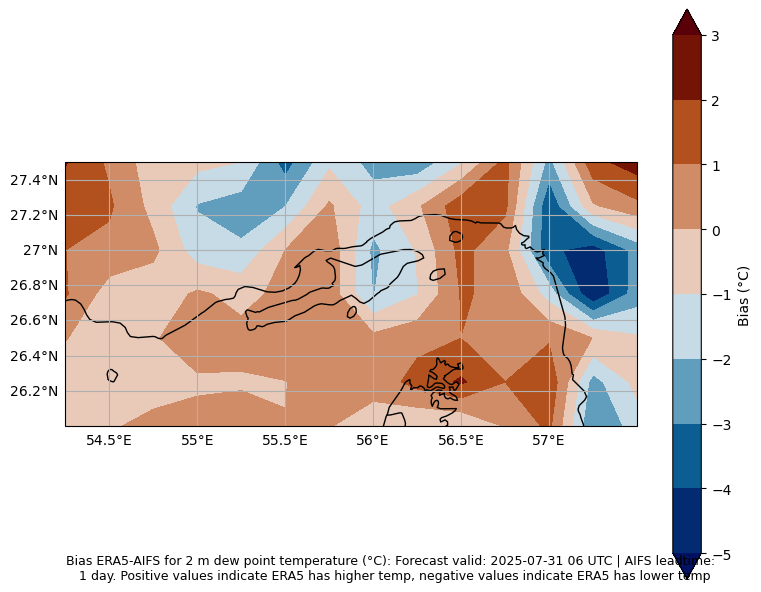

In [63]:
#map of the bias

map_projection = ccrs.PlateCarree()

# Start from dew point in degC and reduce any singleton extra dims
bias_plot = bias
for dim in ["valid_time", "time", "step", "leadtime", "ensemble_members", "number"]:
    if dim in bias_plot.dims:
        bias_plot = bias_plot.isel({dim: 0})

absmax = np.nanmax(np.abs(bias_plot.values))
norm = mcolors.TwoSlopeNorm(vmin=-absmax, vcenter=0, vmax=absmax)

levels = np.linspace(-absmax, absmax, 10)
levels=[-5,-4,-3, -2, -1, 0, 1, 2, 3] #change the levels to make the colors more distinct


# V_levels = np.arange(-11, 6, 0.2)

fig, ax = plt.subplots(1, 1, figsize=(8, 6), subplot_kw={"projection": map_projection})

cf = ax.contourf(
    bias_plot.longitude,
    bias_plot.latitude,
    bias_plot,
    levels=levels,
    cmap=cm.vik,
    transform=map_projection,
    extend="both"
)

ax.add_feature(cfeature.COASTLINE, linestyle='-')
ax.add_feature(cfeature.BORDERS)
gl = ax.gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False

#ax.set_title("Bias ERA5-AIFS for 2 m dew point temperature (°C)", fontsize=11)
fig.colorbar(cf, ax=ax, label="Bias (°C)")

fig.text(
    0.5, 0.02,
    "Bias ERA5-AIFS for 2 m dew point temperature (°C): Forecast valid: 2025-07-31 06 UTC | AIFS leadtime:  \n"
    "1 day. Positive values indicate ERA5 has higher temp, negative values indicate ERA5 has lower temp",
    ha="center", va="bottom", fontsize=9
)

plt.tight_layout(rect=[0, 0.06, 1, 1])  # leave space at bottom for fig.text
plt.tight_layout()

In [62]:
bias_plot.min()

<xarray.DataArray 'd2m_C' ()> Size: 4B
array(-4.9368744, dtype=float32)
Coordinates:
    number             int64 8B ...
    time               datetime64[ns] 8B ...
    step               timedelta64[ns] 8B ...
    surface            float64 8B ...
    valid_time         datetime64[ns] 8B ...
    fc_init_time       datetime64[ns] 8B ...
    heightAboveGround  float64 8B ...
    fc_valid_time      datetime64[ns] 8B 2025-07-31T06:00:00
    leadtime           int64 8B 1
Attributes: (12/27)
    GRIB_paramId:                             168
    GRIB_numberOfPoints:                      13041
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    GRIB_gridType:                            regular_ll
    GRIB_uvRelativeToGrid:                    0
    ...                                       ...
    GRIB_name:                                2 metre dewpoint temperature
    GRIB_shortName:                           2d
    GRIB_units:                               K
    long_name:                                2 metre dewpoint temperature
    units:                                    K
    standard_name:                            unknown